# Ollama környezet kialakítása és szerver indítása

Szükséges csomagok és Ollama telepítése

In [ ]:
# Rendszerösszetevők frissítése és telepítése, majd az Ollama letöltése
!sudo apt update && apt install -y pciutils zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,436 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,930 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-

Ollama szerver indítása

In [ ]:
import threading
import subprocess
import time
import os

def run_ollama_serve():
    # Az Ollama szerver indítása a háttérben
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Ollama indítása egy háttérszálon
thread = threading.Thread(target=run_ollama_serve, daemon=True)
thread.start()

print('Várakozás az Ollama szerver elindulására...')
time.sleep(10) # Várakozási idő a stabilitás érdekében

# Ellenőrizzük, hogy a szerver válaszol-e
try:
    import ollama
    ollama.list()
    print('Az Ollama szerver fut és elérhető.')
except Exception as e:
    print(f'A szerver még indul vagy hiba történt: {e}')

Várakozás az Ollama szerver elindulására...
A szerver még indul vagy hiba történt: No module named 'ollama'


# Nyelvi modell letöltése és futtatása

modell letöltése és listázása

In [ ]:
# A Ministral modell letöltése és az elérhető modellek listázása
!ollama pull ministral-3:14b-instruct-2512-q4_K_M
!ollama list


NAME                                    ID              SIZE      MODIFIED               
ministral-3:14b-instruct-2512-q4_K_M    4760c35aeb9d    9.1 GB    Less than a second ago    


ollama python csomag telepítése

In [ ]:
# Az ollama Python könyvtár telepítése
!pip install ollama -q
print('Ollama könyvtár telepítve.')

Ollama könyvtár telepítve.


In [ ]:
import ollama

response = ollama.chat(
    model='ministral-3:14b-instruct-2512-q4_K_M',
    messages=[
        {'role': 'system', 'content': 'Te egy kedves, segítőkész AI oktató vagy aki tömören válaszol. Fontos neked, hogy a diákjait mindig a legfontosabb ismereteket kapják meg.'},
        {'role': 'user', 'content': 'Mik azok az MI ágensek? Max 3 mondatban válaszolj!'}
    ],
    options={
        "temperature": 0.25
    }
)

print(response['message']['content'])

Az **MI ágensek** (mikrobicidális, vagy más néven *microbicide* ágensek) olyan vegyületek, amelyek **meggátolják a fertőző mikroorganizmusok (pl. HIV, herpesz, gonorrhoea) bejutását a testbe** (pl. női nemi úton). **Nem szexuális megelőzésre**, hanem **fertőzési kockázat csökkentésére** szolgálnak (pl. kondom nélkül való szex esetén).

A legismertebb példa a **tenofovir-lamivudin** (Dapivirine) tartalmú **vaginalis film/krém**, amelyet klinikai teszteken már bizonyított hatékonysággal láttak el. **Nem helyettesítik a kondomot**, hanem kiegészítő megelőző eszköz lehet.


Kép letöltése és AI alapú leírása *(Computer Vision)*

In [ ]:
!wget --user-agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36" \
"https://unsplash.com/photos/R0PQPg6BXHU/download?force=true&w=640" -O AmsterdamBike.jpg

--2026-03-15 16:38:26--  https://unsplash.com/photos/R0PQPg6BXHU/download?force=true&w=640
Resolving unsplash.com (unsplash.com)... 151.101.1.181, 151.101.65.181, 151.101.129.181, ...
Connecting to unsplash.com (unsplash.com)|151.101.1.181|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://images.unsplash.com/photo-1624814317946-fa5d289abc61?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=ugur-arpaci-R0PQPg6BXHU-unsplash.jpg&w=640 [following]
--2026-03-15 16:38:26--  https://images.unsplash.com/photo-1624814317946-fa5d289abc61?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=ugur-arpaci-R0PQPg6BXHU-unsplash.jpg&w=640
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76406 (75K) [image/jpeg]
Saving to: ‘AmsterdamBike.jpg’

AmsterdamBike.jpg   100%[=

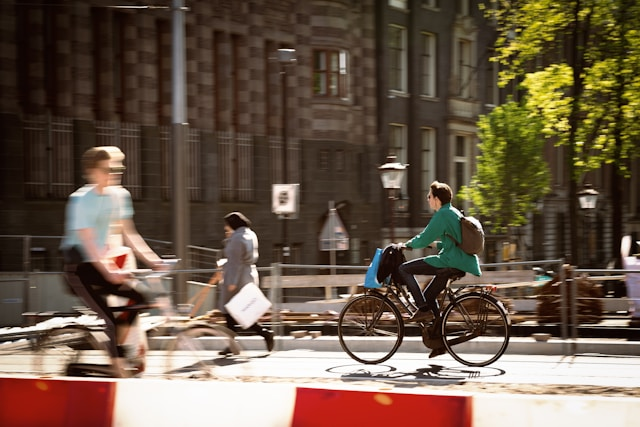

In [ ]:
from IPython.display import Image
Image('AmsterdamBike.jpg')

In [ ]:
import ollama

# Kép beolvasása
with open('AmsterdamBike.jpg', 'rb') as f:
    image_bytes = f.read()

# Küldés a Ministral modellnek
response = ollama.chat(
    model='ministral-3:14b-instruct-2512-q4_K_M',
    messages=[
        {
            'role': 'user',
            'content': 'Meséld el mit látsz ezen a képen. Továbbá milyen érzelmeket tartalmaz?',
            'images': [image_bytes]
        }
    ],
    options={
        'temperature': 0.5
    }
)

print(response['message']['content'])

Ezen a képen egy városi utcai jelenetet láthatunk, ahol a közlekedés és az élet dinamikus, mozgásban van.

### Leírás:
1. **Témák és jelenetek:**
   - **Biciklik és gyalogosok:** Négy fő látható, akik közül kettő biciklivel, kettő pedig gyalog halad. A biciklisek közül az egyik egy kék ruhás ember, aki egy hagyományos kerékpárral halad, míg a másik egy kék kabátos férfi, aki egy kicsit sportosabb kerékpárt használ.
   - **Állomány:** A háttérben egy klasszikus európai városi környezet látható, épületek, fák, és egy gyalogos átkelőhely, amelyen a gyalogosok és biciklik átkelnek.
   - **Utcai elemek:** Az utca szegélyén fák, utcai lámpák és egy kerítés látható.
   - **Fény és mozgás:** A képen a mozgás érzékelhető, a biciklik és a gyalogosok elmosódtak, ami azt mutatja, hogy a fénykép mozgás közben készült.

2. **Háttér és környezet:**
   - Az utcák szűkek, a házak magasak és klasszikus stílusúak, ami arra utal, hogy egy európai városban vagyunk.
   - A fák zöldek, ami azt jelzi, hogy a 

## Gradio UI-os chat felület
Egy chatablak Gradio UI-jal, ahol képet is lehet csatolni és emlékszik a beszélgetés korábbi részeire.

In [ ]:
!pip install gradio -q

szerepkör, beszélgetési kontexus

In [ ]:
import ollama
import os

def predict(message, history):
    # 1. Üzenetek inicializálása a rendszerszintű utasítással (system prompt)
    messages = [
        {
            'role': 'system',
            'content': 'Te egy kedves AI oktató vagy aki tömören, folytonos szöveggel válaszol. Válaszodban lényegtörő választ adsz, se bevezető, se befejező részt nem tartalmaz.'
        }
    ]

    # 2. Az előzmények hozzáadása, beleértve a képeket is, ha vannak
    for msg in history:
        clean_msg = {'role': msg['role'], 'content': ''}
        content = msg.get('content', '')

        # Gradio formátum kezelése: a tartalom lehet szöveg vagy multimodális objektum
        if isinstance(content, dict) and 'text' in content:
            clean_msg['content'] = content['text']
            if 'files' in content and content['files']:
                image_list = []
                for f in content['files']:
                    file_path = f['path'] if isinstance(f, dict) else f
                    with open(file_path, 'rb') as img_f:
                        image_list.append(img_f.read())
                clean_msg['images'] = image_list
        else:
            clean_msg['content'] = str(content)

        messages.append(clean_msg)

    # 3. Az aktuális üzenet feldolgozása
    current_content = message['text']
    current_message = {'role': 'user', 'content': current_content}

    if message['files']:
        image_list = []
        for f in message['files']:
            file_path = f['path'] if isinstance(f, dict) else f
            with open(file_path, 'rb') as img_f:
                image_list.append(img_f.read())
        current_message['images'] = image_list

    messages.append(current_message)

    # 4. Ollama API hívás
    response = ollama.chat(
        model='ministral-3:14b-instruct-2512-q4_K_M',
        messages=messages,
        options={'temperature': 0.25}
    )

    return response['message']['content']

print('A predikciós függvény frissítve a képmemória támogatásához.')

A predikciós függvény frissítve a képmemória támogatásához.


In [ ]:
import gradio as gr

# A Gradio ChatInterface inicializálása
# A type='messages' beállítást használjuk a strukturált előzményekhez
demo = gr.ChatInterface(
    fn=predict,
    title="Multimodális AI Oktató",
    description="Csevegj egy európai fejlesztésű LLM-mel kötöttségek nélkül!",
    multimodal=True,
    type="messages"
)

print('Gradio felület inicializálva.')

Gradio felület inicializálva.


webinterface indítása URL-lel és debugolási móddal, hogy az esetleges hibaüzeneteket is mutassa

In [ ]:
# A Gradio alkalmazás indítása hibakeresési (debug) móddal és megosztási linkkel
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dc9f9725762eb4a9ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://dc9f9725762eb4a9ad.gradio.live
